# Autoencoder
Autoenkoder to rodzaj sieci neuronowej do problemów uczenia bez nadzoru takich jak np. redukcja wymiarów, wykrywanie anomalii czy ekstrakcja cech. Ich działanie opiera się na kompresji danych w formie kodowania i późniejszej ich rekonstrukcji. Celem jest minimalizacja różnic między oryginałem a elementem odtworzonym. 

Przy tym przykładzie również wykorzystamy zbiór danych MNIST.

Tym razem wykorzystamy też trochę mniej bibliotek 

In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

Podobnie jak w przypadku sieci GAN, ładujemy i przygotowujemy zbiór danych. 

In [2]:
tensor_transform = transforms.ToTensor()
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=tensor_transform)
loader = torch.utils.data.DataLoader(dataset=dataset, batch_size=32, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 7.30MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 254kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]


Następnie budujemy model autoenkodera, składający się z dwóch modeli: enkodera i dekodera. 

In [3]:
class AE(nn.Module):
    def __init__(self):
        super(AE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 36),
            nn.ReLU(),
            nn.Linear(36, 18),
            nn.ReLU(),
            nn.Linear(18, 9)
        )
        self.decoder = nn.Sequential(
            nn.Linear(9, 18),
            nn.ReLU(),
            nn.Linear(18, 36),
            nn.ReLU(),
            nn.Linear(36, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

Model następnie inicjalizujemy i ustawiamy jego podstawowe parametry, w tym funkcję straty, optymizację i learning rate. 

In [4]:
model = AE()
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-8)

Następnie możemy przejść do wytrenowania modelu (u mnie, dla 20-stu iteracji było to około dwóch minut) i narysowania wykresu funkcji straty, w celu weryfikacji procesu uczenia się modelu. 

Epoch 1/20, Loss: 0.036594
Epoch 2/20, Loss: 0.030375
Epoch 3/20, Loss: 0.028153
Epoch 4/20, Loss: 0.026475
Epoch 5/20, Loss: 0.024019
Epoch 6/20, Loss: 0.023815
Epoch 7/20, Loss: 0.026449
Epoch 8/20, Loss: 0.026372
Epoch 9/20, Loss: 0.028120
Epoch 10/20, Loss: 0.018501
Epoch 11/20, Loss: 0.022044
Epoch 12/20, Loss: 0.024726
Epoch 13/20, Loss: 0.019639
Epoch 14/20, Loss: 0.023528
Epoch 15/20, Loss: 0.020802
Epoch 16/20, Loss: 0.017980
Epoch 17/20, Loss: 0.015786
Epoch 18/20, Loss: 0.019704
Epoch 19/20, Loss: 0.014520
Epoch 20/20, Loss: 0.020739


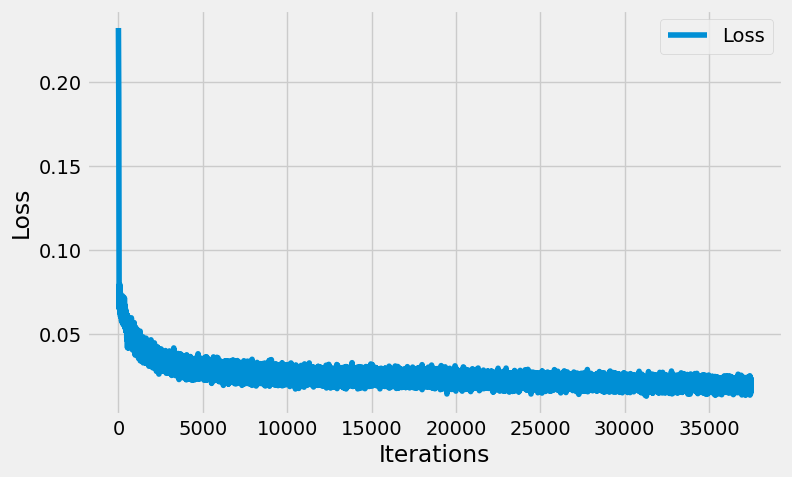

In [5]:
epochs = 20
outputs = []
losses = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(epochs):
    for images, _ in loader:
        images = images.view(-1, 28 * 28).to(device)
        
        reconstructed = model(images)
        loss = loss_function(reconstructed, images)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
    
    outputs.append((epoch, images, reconstructed))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

torch.save(model, "Autoencoder")

plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

W celu ostatecznej weryfikacji można zwizualizować wyniki działania modelu dla serii obrazów, pokazując obraz oryginalny, oraz wynikowy, przepuszczony przez model. 

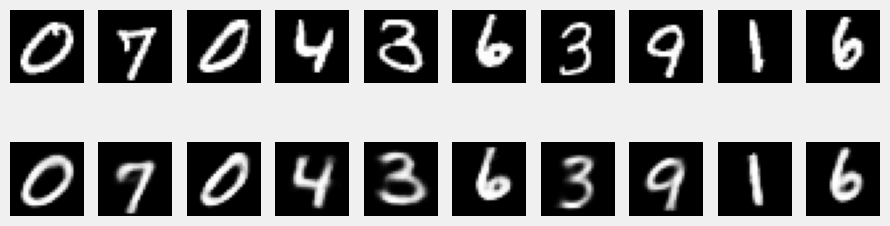

In [10]:
model.eval()
dataiter = iter(loader)
images, _ = next(dataiter)

images = images.view(-1, 28 * 28).to(device)
reconstructed = model(images)

fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(10, 3))
for i in range(10):
    axes[0, i].imshow(images[i].cpu().detach().numpy().reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i].cpu().detach().numpy().reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
plt.show()

Jak widzimy, model nie działa idealnie, jest jednak stosunkowo bliko oryginalnych obrazów. Można np. spróbować przedłużyć trening modelu i sprawdzić jak będzie sobie radził przy większej liczbie epok, jednak patrząc na wykres funkcji straty, ryzyko przetrenowania jest stosunkowo duże - potencjalnie możnaby nawet sprawdzić, czy model nie będzie radził sobie lepij przy krótszym treningu. 

Większość z efektów w wynikowych obrazach wynika z charakterystyki modelu - jako że wykorzystujemy kompresję, rozmycie obrazu jest raczej oczekiwane. Innym podejściem, kótre może poprawić jakość wyników jest wykorzystanie bardziej rozbudowanej struktury, przy czym wtedy oczywiście wydłuży się czas trenowania modelu. 